In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1) ANN Model

In [ ]:
df = pd.read_excel("NGAsub_MegaFlatfile_RotD50_050_R211022_public.xlsx")

In [ ]:
df.head()

,NGAsubRSN,DatabaseRegion,NGAsubEQID,NGAsubSSN,Earthquake_Name,YEAR,MODY,HRMN,Earthquake_Magnitude,Hypocenter_Latitude_deg,...,T8pt500S,T9pt000S,T9pt500S,T10pt000S,T11pt000S,T12pt000S,T13pt000S,T14pt000S,T15pt000S,T20pt000S
0,1000001,Alaska,1000001,1000001,Aleutian_Isl-Alaska,2014,623,2053,7.96,51.6928,...,0.000082,0.000095,0.000103,0.000125,0.000138,0.000109,0.000089,0.000064,0.000053,0.000061
1,1000002,Alaska,1000001,1000002,Aleutian_Isl-Alaska,2014,623,2053,7.96,51.6928,...,0.000415,0.000395,0.000405,0.000390,0.000336,0.000332,0.000263,0.000215,0.000187,0.000119
2,1000003,Alaska,1000001,1000003,Aleutian_Isl-Alaska,2014,623,2053,7.96,51.6928,...,0.000092,0.000083,0.000086,0.000082,0.000091,0.000078,0.000071,0.000066,0.000060,0.000055
3,1000004,Alaska,1000001,1000004,Aleutian_Isl-Alaska,2014,623,2053,7.96,51.6928,...,0.000055,0.000053,0.000051,0.000055,0.000059,0.000058,0.000042,0.000035,0.000038,0.000028
4,1000005,Alaska,1000001,1000005,Aleutian_Isl-Alaska,2014,623,2053,7.96,51.6928,...,0.000129,0.000116,0.000128,0.000122,0.000130,0.000119,0.000096,0.000135,0.000162,0.000060


In [ ]:
df['Fault_Type']

0        0
1        0
2        0
3        0
4        0
        ..
71335    0
71336    0
71337    0
71338    0
71339    0
Name: Fault_Type, Length: 71340, dtype: int64

In [ ]:
# 1)M - Earthquake_Magnitude - we need to screen the data for M>=4 only
#2) Distance R: Rjb_km >=0 and Rjb_km <=500km only
#3) remove rows with parameters [M, R, Vs30, FM]<0
df_filtered = df[(df['Earthquake_Magnitude'] >= 4) & (df['Rjb_km'] >= 0) & (df['Rjb_km'] <= 500) &
                 (df['Vs30_Selected_for_Analysis_m_s'] > 0) & (df['Fault_Type'] > 0)]


In [ ]:
print(df.shape, df_filtered.shape)

(71340, 227) (45675, 227)


In [ ]:
df_filtered['Fault_Type'].value_counts()

Fault_Type
2    25826
3     9387
1     7225
4     3237
Name: count, dtype: int64

In [ ]:
#input variables
# Earthquake_Magnitude - Mw
# Vs30_Selected_for_Analysis_m_s -> Log_Vs30
# Rjb_km -> R_Rup
# Rjb_km -> Log_R_Rup
# Fault_Type -> F
#these all are the input variables

#Output variable
# PGA_g, PGV_cm_sec, and 20 cols as described below
#T0pt010S - this means T = 0.010s, so we need to take 20 cols starting from T0pt010S,..


In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np

# =========================
# INPUT PREPARATION
# =========================

# Log transforms (inputs are already filtered >0)
df_filtered["Log_Vs30"] = np.log10(df_filtered["Vs30_Selected_for_Analysis_m_s"])
epsilon = 1e-3  # 1 meter
df_filtered["Log_R_Rup"] = np.log10(df_filtered["Rjb_km"] + epsilon)


# Numerical inputs
X_numeric = df_filtered[
    ["Earthquake_Magnitude", "Log_Vs30", "Rjb_km", "Log_R_Rup"]
].values

# One-hot encode Fault_Type (1,2,3,4)
encoder = OneHotEncoder(categories=[[1, 2, 3, 4]], sparse_output=False)
F_encoded = encoder.fit_transform(df_filtered[["Fault_Type"]])

# Final input matrix
X = np.hstack([X_numeric, F_encoded])

print("Input matrix shape:", X.shape)


# =========================
# OUTPUT PREPARATION
# =========================

# Select first 20 SA columns starting from T0pt010S
sa_cols = df_filtered.loc[:, "T0pt010S":"T20pt000S"].columns[:20]

output_cols = ["PGA_g", "PGV_cm_sec"] + list(sa_cols)

# Raw outputs
Y_raw = df_filtered[output_cols].values

# Mask rows with non-positive outputs
valid_mask = np.all(Y_raw > 0, axis=1)

print("Rows before filter:", Y_raw.shape[0])
print("Rows after filter :", valid_mask.sum())

# Apply mask
X = X[valid_mask]
Y = np.log10(Y_raw[valid_mask])

# Sanity checks
print("NaNs in X:", np.isnan(X).any())
print("NaNs in Y:", np.isnan(Y).any())
print("Infs in Y:", np.isinf(Y).any())


# =========================
# STANDARDIZATION
# =========================

scaler_X = StandardScaler()
X = scaler_X.fit_transform(X)


# =========================
# TRAIN–TEST SPLIT
# =========================

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape, Y_train.shape)


# =========================
# ANN MODEL
# =========================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Dense(16, activation='relu', input_shape=(X.shape[1],)),
    Dense(22, activation='linear')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()


# =========================
# TRAIN
# =========================

history = model.fit(
    X_train, Y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    verbose=1
)


# =========================
# EVALUATE
# =========================

test_loss, test_mae = model.evaluate(X_test, Y_test, verbose=0)
print("Test MSE:", test_loss)
print("Test MAE:", test_mae)


C:\Users\vishnu vardhan\AppData\Local\Temp\ipykernel_36792\1364704427.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Log_Vs30"] = np.log10(df_filtered["Vs30_Selected_for_Analysis_m_s"])
C:\Users\vishnu vardhan\AppData\Local\Temp\ipykernel_36792\1364704427.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Log_R_Rup"] = np.log10(df_filtered["Rjb_km"] + epsilon)
c:\Users\vishnu vardhan\anaconda3\envs\tfenv\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do no

Input matrix shape: (45675, 8)
Rows before filter: 45675
Rows after filter : 45607
NaNs in X: False
NaNs in Y: False
Infs in Y: False
Training set: (36485, 8) (36485, 22)


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_49 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 22)             │           374 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 518 (2.02 KB)

 Trainable params: 518 (2.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4.0537 - mae: 1.8061 - val_loss: 2.0951 - val_mae: 1.2299
Epoch 2/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.5412 - mae: 1.0217 - val_loss: 0.5796 - val_mae: 0.5936
Epoch 3/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4922 - mae: 0.5344 - val_loss: 0.3302 - val_mae: 0.4376
Epoch 4/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3208 - mae: 0.4257 - val_loss: 0.2663 - val_mae: 0.3912
Epoch 5/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2627 - mae: 0.3842 - val_loss: 0.2356 - val_mae: 0.3668
Epoch 6/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2320 - mae: 0.3622 - val_loss: 0.2198 - val_mae: 0.3534
Epoch 7/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2138 - mae: 0.3514 - val_loss: 0.2104 - val_mae: 0.3451
Epoch 8/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2066 - mae: 0.3409 - val_loss: 0.2038 - val_mae: 0.3392
Epoch 9/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/

In [ ]:
from sklearn.metrics import r2_score

# Predict on test set
Y_pred = model.predict(X_test)

# Overall R² (variance-weighted across all outputs)
r2_overall = r2_score(Y_test, Y_pred, multioutput='variance_weighted')

print("Overall R²:", r2_overall)

286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 945us/step
Overall R²: 0.6726312579806052


In [ ]:
r2_each = r2_score(Y_test, Y_pred, multioutput='raw_values')

for i, r2 in enumerate(r2_each):
    print(f"Output {i+1:02d} R² = {r2:.3f}")


Output 01 R² = 0.687
Output 02 R² = 0.774
Output 03 R² = 0.686
Output 04 R² = 0.684
Output 05 R² = 0.684
Output 06 R² = 0.683
Output 07 R² = 0.680
Output 08 R² = 0.680
Output 09 R² = 0.678
Output 10 R² = 0.675
Output 11 R² = 0.674
Output 12 R² = 0.671
Output 13 R² = 0.669
Output 14 R² = 0.667
Output 15 R² = 0.666
Output 16 R² = 0.664
Output 17 R² = 0.661
Output 18 R² = 0.659
Output 19 R² = 0.652
Output 20 R² = 0.646
Output 21 R² = 0.640
Output 22 R² = 0.638


Graphs

1) Residuals

In [ ]:
# Predict on test set
Y_pred = model.predict(X_test)

# Residuals in log10 space
residuals = Y_test - Y_pred

# PGA residuals (index 0)
res_pga = residuals[:, 0]


286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 908us/step


In [ ]:
# Get indices of test samples
_, X_test_idx = train_test_split(
    np.arange(len(X)),
    test_size=0.2,
    random_state=42
)

Mw_test = df_filtered.loc[valid_mask].iloc[X_test_idx]["Earthquake_Magnitude"].values
Rrup_test = df_filtered.loc[valid_mask].iloc[X_test_idx]["Rjb_km"].values
Vs30_test = df_filtered.loc[valid_mask].iloc[X_test_idx]["Vs30_Selected_for_Analysis_m_s"].values


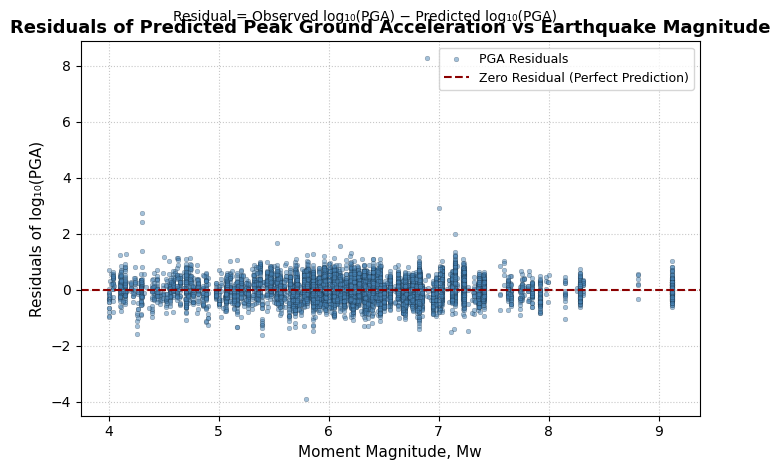

In [ ]:
plt.figure(figsize=(7,5))

# Scatter plot
plt.scatter(
    Mw_test,
    res_pga,
    s=12,
    color='steelblue',
    alpha=0.5,
    edgecolor='k',
    linewidth=0.2,
    label='PGA Residuals'
)

# Zero residual reference line
plt.axhline(
    y=0,
    color='darkred',
    linestyle='--',
    linewidth=1.5,
    label='Zero Residual (Perfect Prediction)'
)

# Labels
plt.xlabel("Moment Magnitude, Mw", fontsize=11)
plt.ylabel("Residuals of log₁₀(PGA)", fontsize=11)

# Title and subtitle
plt.title(
    "Residuals of Predicted Peak Ground Acceleration vs Earthquake Magnitude",
    fontsize=13,
    fontweight='bold'
)
plt.suptitle(
    "Residual = Observed log₁₀(PGA) − Predicted log₁₀(PGA)",
    fontsize=10,
    y=0.93
)

# Grid and legend
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(frameon=True, fontsize=9)

plt.tight_layout()
plt.show()


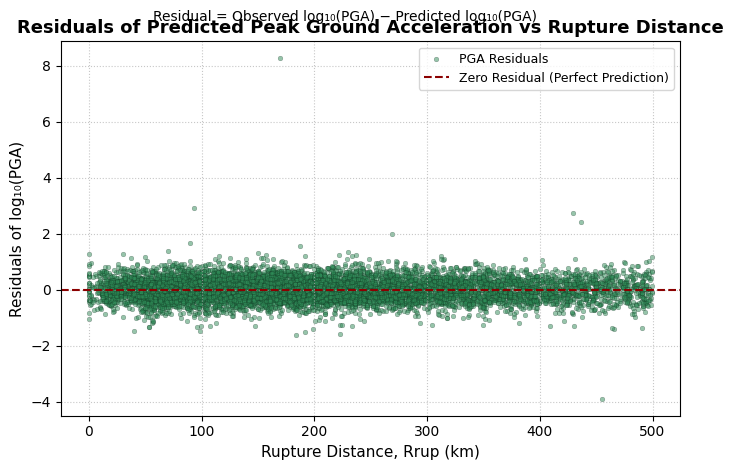

In [ ]:
plt.figure(figsize=(7,5))

# Scatter plot
plt.scatter(
    Rrup_test,
    res_pga,
    s=12,
    color='seagreen',
    alpha=0.5,
    edgecolor='k',
    linewidth=0.2,
    label='PGA Residuals'
)

# Zero residual reference line
plt.axhline(
    y=0,
    color='darkred',
    linestyle='--',
    linewidth=1.5,
    label='Zero Residual (Perfect Prediction)'
)

# Labels
plt.xlabel("Rupture Distance, Rrup (km)", fontsize=11)
plt.ylabel("Residuals of log₁₀(PGA)", fontsize=11)

# Title and subtitle
plt.title(
    "Residuals of Predicted Peak Ground Acceleration vs Rupture Distance",
    fontsize=13,
    fontweight='bold'
)
plt.suptitle(
    "Residual = Observed log₁₀(PGA) − Predicted log₁₀(PGA)",
    fontsize=10,
    y=0.93
)

# Grid and legend
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(frameon=True, fontsize=9)

plt.tight_layout()
plt.show()


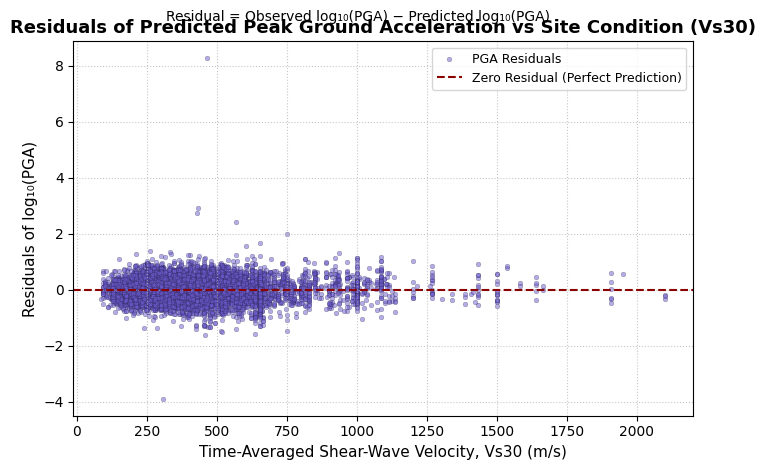

In [ ]:
plt.figure(figsize=(7,5))

# Scatter plot
plt.scatter(
    Vs30_test,
    res_pga,
    s=12,
    color='slateblue',
    alpha=0.5,
    edgecolor='k',
    linewidth=0.2,
    label='PGA Residuals'
)

# Zero residual reference line
plt.axhline(
    y=0,
    color='darkred',
    linestyle='--',
    linewidth=1.5,
    label='Zero Residual (Perfect Prediction)'
)

# Labels
plt.xlabel("Time-Averaged Shear-Wave Velocity, Vs30 (m/s)", fontsize=11)
plt.ylabel("Residuals of log₁₀(PGA)", fontsize=11)

# Title and subtitle
plt.title(
    "Residuals of Predicted Peak Ground Acceleration vs Site Condition (Vs30)",
    fontsize=13,
    fontweight='bold'
)
plt.suptitle(
    "Residual = Observed log₁₀(PGA) − Predicted log₁₀(PGA)",
    fontsize=10,
    y=0.93
)

# Grid and legend
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(frameon=True, fontsize=9)

plt.tight_layout()
plt.show()


2) Hyper parameter tuning
B. Network hyperparameters

Batch size

Learning rate

Number of hidden neurons

STEP 1 — Tune Number of Hidden Neurons

This usually has the largest impact.

Values to test (reasonable range)

In [ ]:
hidden_units_list = [8, 12, 16, 20, 24, 32]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

results_hidden = []

for H in hidden_units_list:
    model = Sequential([
        Dense(H, activation='relu', input_shape=(X.shape[1],)),
        Dense(22, activation='linear')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

    history = model.fit(
        X_train, Y_train,
        validation_split=0.2,
        epochs=80,
        batch_size=256,
        verbose=0
    )

    min_val_mae = min(history.history['val_mae'])
    results_hidden.append((H, min_val_mae))

    print(f"Hidden neurons: {H}, Min Val MAE: {min_val_mae:.4f}")


c:\Users\vishnu vardhan\anaconda3\envs\tfenv\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Hidden neurons: 8, Min Val MAE: 0.3117
Hidden neurons: 12, Min Val MAE: 0.3083
Hidden neurons: 16, Min Val MAE: 0.3083
Hidden neurons: 20, Min Val MAE: 0.3067
Hidden neurons: 24, Min Val MAE: 0.3062
Hidden neurons: 32, Min Val MAE: 0.3063


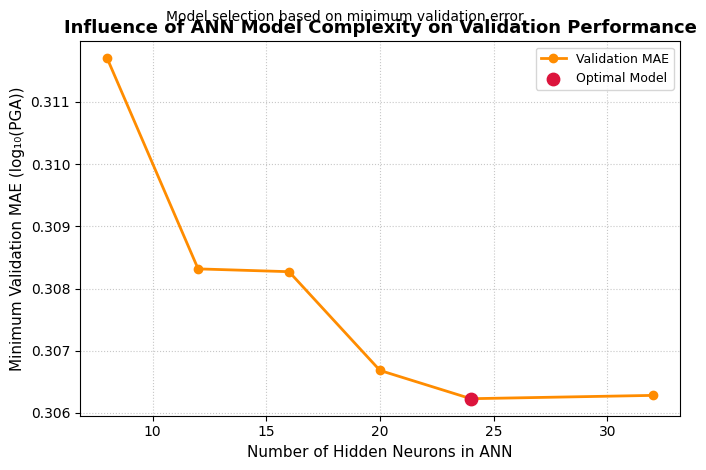

In [ ]:
Hs, maes = zip(*results_hidden)

plt.figure(figsize=(7,5))

plt.plot(
    Hs,
    maes,
    marker='o',
    markersize=6,
    linewidth=2,
    color='darkorange',
    label='Validation MAE'
)

# Highlight best model
best_idx = maes.index(min(maes))
plt.scatter(
    Hs[best_idx],
    maes[best_idx],
    color='crimson',
    s=80,
    zorder=5,
    label='Optimal Model'
)

# Labels
plt.xlabel("Number of Hidden Neurons in ANN", fontsize=11)
plt.ylabel("Minimum Validation MAE (log₁₀(PGA))", fontsize=11)

# Title and subtitle
plt.title(
    "Influence of ANN Model Complexity on Validation Performance",
    fontsize=13,
    fontweight='bold'
)
plt.suptitle(
    "Model selection based on minimum validation error",
    fontsize=10,
    y=0.93
)

# Grid and legend
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(frameon=True, fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
lr_list = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]

In [ ]:
best_H = min(results_hidden, key=lambda x: x[1])[0]

results_lr = []

for lr in lr_list:
    model = Sequential([
        Dense(best_H, activation='relu', input_shape=(X.shape[1],)),
        Dense(22, activation='linear')
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='mse',
        metrics=['mae']
    )

    history = model.fit(
        X_train, Y_train,
        validation_split=0.2,
        epochs=80,
        batch_size=256,
        verbose=0
    )

    min_val_mae = min(history.history['val_mae'])
    results_lr.append((lr, min_val_mae))

    print(f"LR: {lr}, Min Val MAE: {min_val_mae:.4f}")


LR: 0.0001, Min Val MAE: 0.3232
LR: 0.0003, Min Val MAE: 0.3124
LR: 0.001, Min Val MAE: 0.3073
LR: 0.003, Min Val MAE: 0.3038
LR: 0.01, Min Val MAE: 0.3034


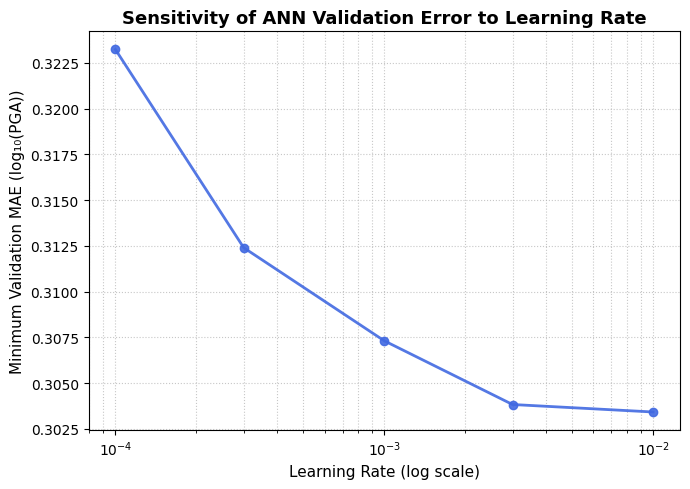

In [ ]:
lrs, maes = zip(*results_lr)

plt.figure(figsize=(7,5))

plt.semilogx(
    lrs,
    maes,
    marker='o',
    markersize=6,
    linewidth=2,
    color='royalblue',
    alpha=0.9
)

# Zero reference not needed here, but grid clarity improved
plt.xlabel("Learning Rate (log scale)", fontsize=11)
plt.ylabel("Minimum Validation MAE (log₁₀(PGA))", fontsize=11)

plt.title(
    "Sensitivity of ANN Validation Error to Learning Rate",
    fontsize=13,
    fontweight='bold'
)

plt.grid(True, which='both', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()


In [ ]:
batch_sizes = [64, 128, 256, 512]

In [ ]:
best_lr = min(results_lr, key=lambda x: x[1])[0]

results_bs = []

for bs in batch_sizes:
    model = Sequential([
        Dense(best_H, activation='relu', input_shape=(X.shape[1],)),
        Dense(22, activation='linear')
    ])

    model.compile(
        optimizer=Adam(learning_rate=best_lr),
        loss='mse',
        metrics=['mae']
    )

    history = model.fit(
        X_train, Y_train,
        validation_split=0.2,
        epochs=80,
        batch_size=bs,
        verbose=0
    )

    min_val_mae = min(history.history['val_mae'])
    results_bs.append((bs, min_val_mae))

    print(f"Batch size: {bs}, Min Val MAE: {min_val_mae:.4f}")


Batch size: 64, Min Val MAE: 0.3062
Batch size: 128, Min Val MAE: 0.3028
Batch size: 256, Min Val MAE: 0.3040
Batch size: 512, Min Val MAE: 0.3052


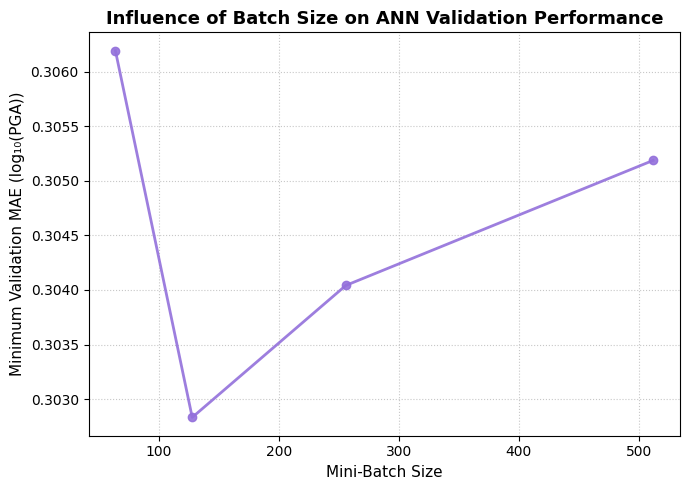

In [ ]:
bss, maes = zip(*results_bs)

plt.figure(figsize=(7,5))

plt.plot(
    bss,
    maes,
    marker='o',
    markersize=6,
    linewidth=2,
    color='mediumpurple',
    alpha=0.9
)

# Labels
plt.xlabel("Mini-Batch Size", fontsize=11)
plt.ylabel("Minimum Validation MAE (log₁₀(PGA))", fontsize=11)

# Title
plt.title(
    "Influence of Batch Size on ANN Validation Performance",
    fontsize=13,
    fontweight='bold'
)

# Grid
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()



In [ ]:
from tensorflow.keras.layers import Dropout

dropout_list = [0.0, 0.1, 0.2, 0.3]
dropout_results = []

for dr in dropout_list:
    model = Sequential([
        Dense(24, activation='relu', input_shape=(X.shape[1],)),
        Dropout(dr),
        Dense(22, activation='linear')
    ])

    model.compile(
        optimizer=Adam(learning_rate=3e-3),
        loss='mse',
        metrics=['mae']
    )

    history = model.fit(
        X_train, Y_train,
        validation_split=0.2,
        epochs=60,
        batch_size=64,
        verbose=0
    )

    dropout_results.append((dr, min(history.history['val_mae'])))
    print(f"Dropout {dr}: Min Val MAE = {min(history.history['val_mae']):.4f}")


Dropout 0.0: Min Val MAE = 0.3042
Dropout 0.1: Min Val MAE = 0.3085
Dropout 0.2: Min Val MAE = 0.3099


KeyboardInterrupt: 

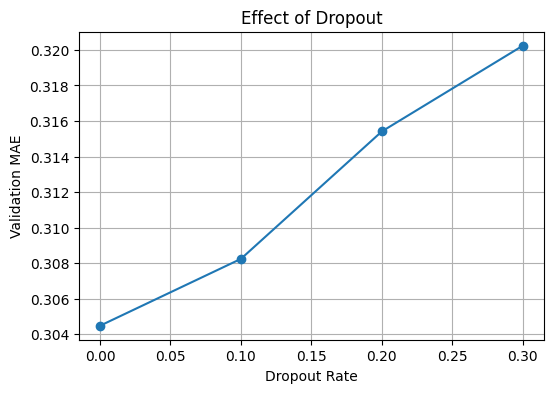

In [ ]:
dr, mae = zip(*dropout_results)

plt.figure(figsize=(6,4))
plt.plot(dr, mae, marker='o')
plt.xlabel("Dropout Rate")
plt.ylabel("Validation MAE")
plt.title("Effect of Dropout")
plt.grid(True)
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# =========================
# FINAL MODEL
# =========================

final_model = Sequential([
    Dense(24, activation='relu', input_shape=(X.shape[1],)),
    Dense(22, activation='linear')
])

final_model.compile(
    optimizer=Adam(learning_rate=3e-3),
    loss='mse',
    metrics=['mae']
)

final_model.summary()


# =========================
# TRAIN FINAL MODEL
# =========================

history_final = final_model.fit(
    X_train, Y_train,
    validation_split=0.2,
    epochs=120,          # slightly higher for final convergence
    batch_size=64,
    verbose=1
)


c:\Users\vishnu vardhan\anaconda3\envs\tfenv\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_42"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_91 (Dense)                │ (None, 24)             │           216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_92 (Dense)                │ (None, 22)             │           550 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 766 (2.99 KB)

 Trainable params: 766 (2.99 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/120
457/457 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.3071 - mae: 0.8100 - val_loss: 0.1897 - val_mae: 0.3251
Epoch 2/120
457/457 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2154 - mae: 0.3259 - val_loss: 0.1850 - val_mae: 0.3211
Epoch 3/120
457/457 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2147 - mae: 0.3223 - val_loss: 0.1812 - val_mae: 0.3164
Epoch 4/120
457/457 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1907 - mae: 0.3138 - val_loss: 0.1806 - val_mae: 0.3169
Epoch 5/120
457/457 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1870 - mae: 0.3147 - val_loss: 0.1792 - val_mae: 0.3147
Epoch 6/120
457/457 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1910 - mae: 0.3137 - val_loss: 0.1765 - val_mae: 0.3115
Epoch 7/120
457/457 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1880 - mae: 0.3123 - val_loss: 0.1740 - val_mae: 0.3088
Epoch 8/120
457/457 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1738 - mae: 0.3117 - val_loss: 0.1741 - val_mae: 0.3096
Epoch 9/120
457/457 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/

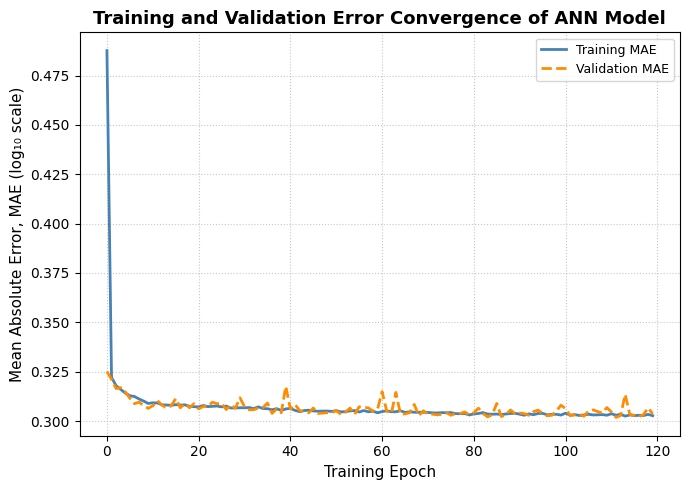

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(
    history_final.history['mae'],
    linewidth=2,
    color='steelblue',
    label='Training MAE'
)

plt.plot(
    history_final.history['val_mae'],
    linewidth=2,
    color='darkorange',
    linestyle='--',
    label='Validation MAE'
)

# Labels
plt.xlabel("Training Epoch", fontsize=11)
plt.ylabel("Mean Absolute Error, MAE (log₁₀ scale)", fontsize=11)

# Title
plt.title(
    "Training and Validation Error Convergence of ANN Model",
    fontsize=13,
    fontweight='bold'
)

# Grid and legend
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(frameon=True, fontsize=9)

plt.tight_layout()
plt.show()



In [ ]:
test_mse, test_mae = final_model.evaluate(X_test, Y_test, verbose=0)

print("Final Test MSE:", test_mse)
print("Final Test MAE:", test_mae)


Final Test MSE: 0.16064026951789856
Final Test MAE: 0.30466750264167786


In [ ]:
from sklearn.metrics import r2_score

Y_test_pred = final_model.predict(X_test)

# Overall R²
r2_overall = r2_score(Y_test, Y_test_pred, multioutput='variance_weighted')
print("Final Overall R²:", r2_overall)

# Per-output R²
r2_each = r2_score(Y_test, Y_test_pred, multioutput='raw_values')

for i, r2 in enumerate(r2_each):
    print(f"Output {i+1:02d} R² = {r2:.3f}")


286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Final Overall R²: 0.676898727561913
Output 01 R² = 0.690
Output 02 R² = 0.776
Output 03 R² = 0.689
Output 04 R² = 0.688
Output 05 R² = 0.687
Output 06 R² = 0.686
Output 07 R² = 0.684
Output 08 R² = 0.684
Output 09 R² = 0.682
Output 10 R² = 0.680
Output 11 R² = 0.679
Output 12 R² = 0.676
Output 13 R² = 0.673
Output 14 R² = 0.671
Output 15 R² = 0.670
Output 16 R² = 0.668
Output 17 R² = 0.666
Output 18 R² = 0.663
Output 19 R² = 0.657
Output 20 R² = 0.651
Output 21 R² = 0.645
Output 22 R² = 0.643


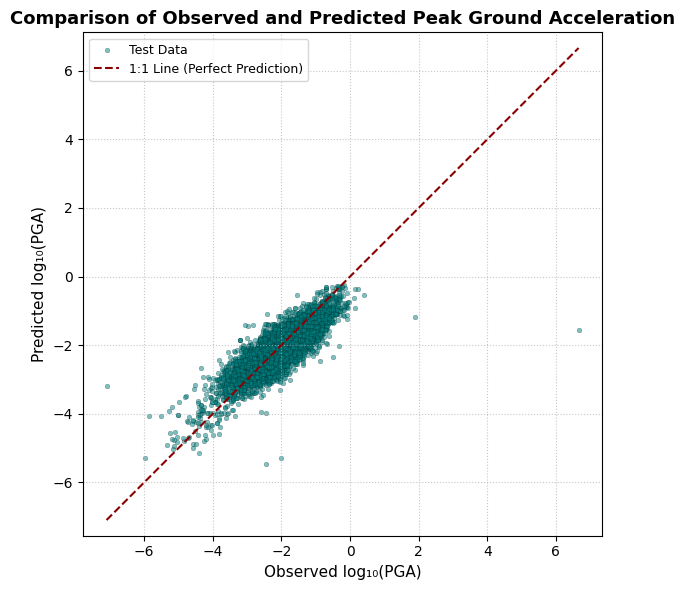

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(
    Y_test[:, 0],
    Y_test_pred[:, 0],
    s=12,
    alpha=0.5,
    color='teal',
    edgecolor='k',
    linewidth=0.2,
    label='Test Data'
)

# 1:1 reference line
min_val = min(Y_test[:, 0].min(), Y_test_pred[:, 0].min())
max_val = max(Y_test[:, 0].max(), Y_test_pred[:, 0].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--',
    color='darkred',
    linewidth=1.5,
    label='1:1 Line (Perfect Prediction)'
)

# Labels
plt.xlabel("Observed log₁₀(PGA)", fontsize=11)
plt.ylabel("Predicted log₁₀(PGA)", fontsize=11)

# Title
plt.title(
    "Comparison of Observed and Predicted Peak Ground Acceleration",
    fontsize=13,
    fontweight='bold'
)

# Grid and legend
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(frameon=True, fontsize=9)

plt.axis('equal')
plt.tight_layout()
plt.show()



In [ ]:
def binned_stats(x, y, bins):
    bin_means = []
    bin_stds = []
    bin_centers = []

    for i in range(len(bins)-1):
        mask = (x >= bins[i]) & (x < bins[i+1])
        if np.sum(mask) > 20:  # avoid empty/noisy bins
            bin_means.append(np.mean(y[mask]))
            bin_stds.append(np.std(y[mask]))
            bin_centers.append(0.5 * (bins[i] + bins[i+1]))

    return np.array(bin_centers), np.array(bin_means), np.array(bin_stds)


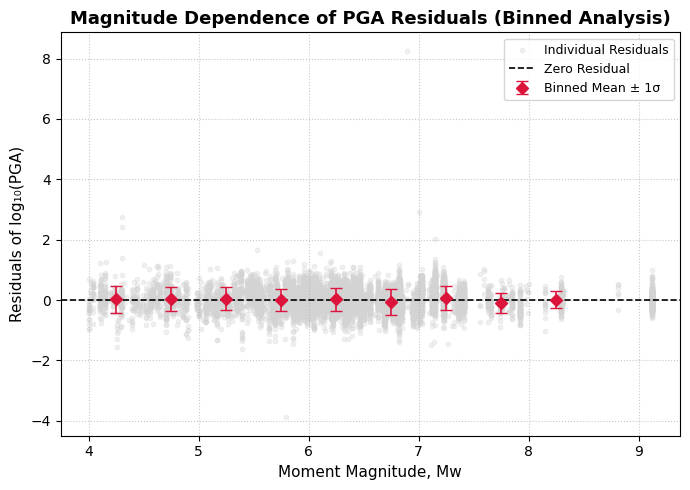

In [ ]:
bins_M = np.linspace(4, 8.5, 10)
bc, bm, bs = binned_stats(Mw_test, res_pga, bins_M)

plt.figure(figsize=(7,5))

# Raw residuals
plt.scatter(
    Mw_test,
    res_pga,
    s=10,
    alpha=0.3,
    color='lightgray',
    label='Individual Residuals'
)

# Binned mean ± std
plt.errorbar(
    bc,
    bm,
    yerr=bs,
    fmt='D',
    color='crimson',
    ecolor='crimson',
    elinewidth=1.2,
    capsize=4,
    markersize=6,
    label='Binned Mean ± 1σ'
)

# Zero residual reference
plt.axhline(
    0,
    color='black',
    linestyle='--',
    linewidth=1.2,
    label='Zero Residual'
)

# Labels
plt.xlabel("Moment Magnitude, Mw", fontsize=11)
plt.ylabel("Residuals of log₁₀(PGA)", fontsize=11)

# Title
plt.title(
    "Magnitude Dependence of PGA Residuals (Binned Analysis)",
    fontsize=13,
    fontweight='bold'
)

# Grid and legend
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(frameon=True, fontsize=9)

plt.tight_layout()
plt.show()



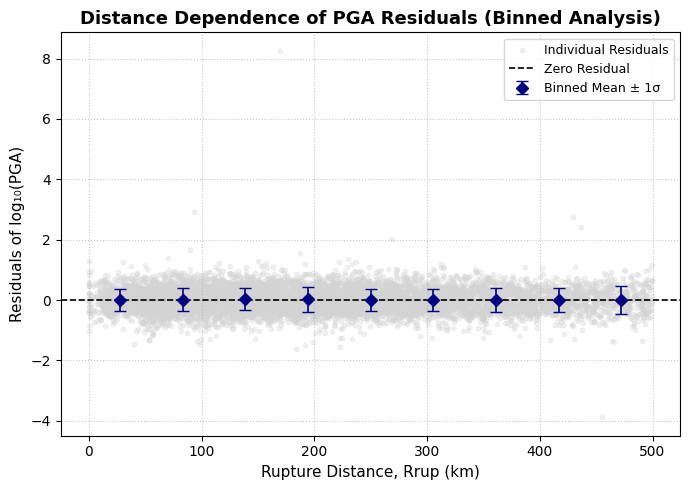

In [ ]:
bins_R = np.linspace(0, 500, 10)
bc, bm, bs = binned_stats(Rrup_test, res_pga, bins_R)

plt.figure(figsize=(7,5))

# Raw residuals
plt.scatter(
    Rrup_test,
    res_pga,
    s=10,
    alpha=0.3,
    color='lightgray',
    label='Individual Residuals'
)

# Binned mean ± std
plt.errorbar(
    bc,
    bm,
    yerr=bs,
    fmt='D',
    color='navy',
    ecolor='navy',
    elinewidth=1.2,
    capsize=4,
    markersize=6,
    label='Binned Mean ± 1σ'
)

# Zero residual reference
plt.axhline(
    0,
    color='black',
    linestyle='--',
    linewidth=1.2,
    label='Zero Residual'
)

# Labels
plt.xlabel("Rupture Distance, Rrup (km)", fontsize=11)
plt.ylabel("Residuals of log₁₀(PGA)", fontsize=11)

# Title
plt.title(
    "Distance Dependence of PGA Residuals (Binned Analysis)",
    fontsize=13,
    fontweight='bold'
)

# Grid and legend
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(frameon=True, fontsize=9)

plt.tight_layout()
plt.show()


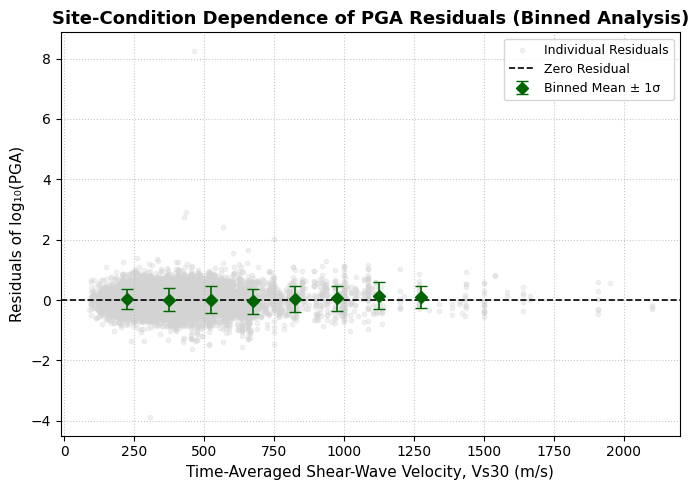

In [ ]:
bins_V = np.linspace(150, 1500, 10)
bc, bm, bs = binned_stats(Vs30_test, res_pga, bins_V)

plt.figure(figsize=(7,5))

# Raw residuals
plt.scatter(
    Vs30_test,
    res_pga,
    s=10,
    alpha=0.3,
    color='lightgray',
    label='Individual Residuals'
)

# Binned mean ± std
plt.errorbar(
    bc,
    bm,
    yerr=bs,
    fmt='D',
    color='darkgreen',
    ecolor='darkgreen',
    elinewidth=1.2,
    capsize=4,
    markersize=6,
    label='Binned Mean ± 1σ'
)

# Zero residual reference
plt.axhline(
    0,
    color='black',
    linestyle='--',
    linewidth=1.2,
    label='Zero Residual'
)

# Labels
plt.xlabel("Time-Averaged Shear-Wave Velocity, Vs30 (m/s)", fontsize=11)
plt.ylabel("Residuals of log₁₀(PGA)", fontsize=11)

# Title
plt.title(
    "Site-Condition Dependence of PGA Residuals (Binned Analysis)",
    fontsize=13,
    fontweight='bold'
)

# Grid and legend
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(frameon=True, fontsize=9)

plt.tight_layout()
plt.show()



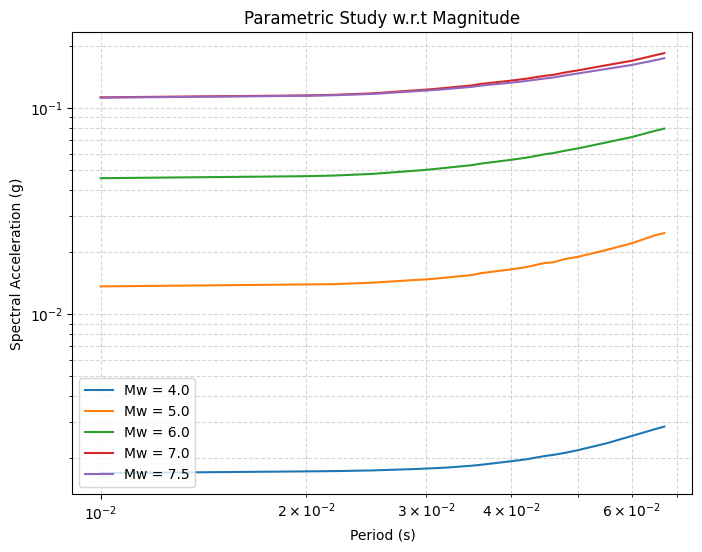

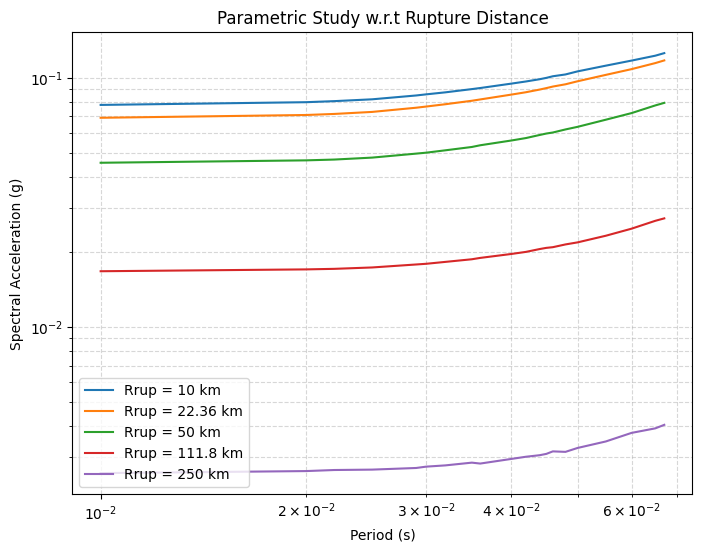

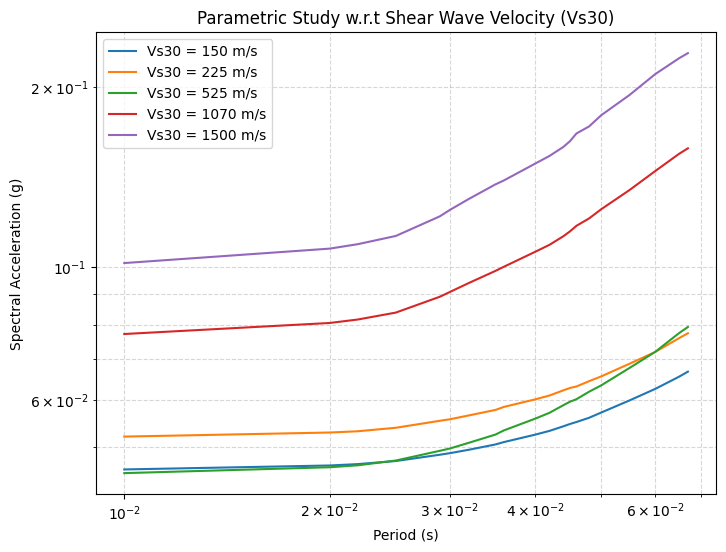

c:\Users\vishnu vardhan\anaconda3\envs\tfenv\lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
c:\Users\vishnu vardhan\anaconda3\envs\tfenv\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_147
Received: inputs=['Tensor(shape=(100, 8))']
  warnings.warn(msg)
c:\Users\vishnu vardhan\anaconda3\envs\tfenv\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_147
Received: inputs=['Tensor(shape=(200, 8))']
  warnings.warn(msg)


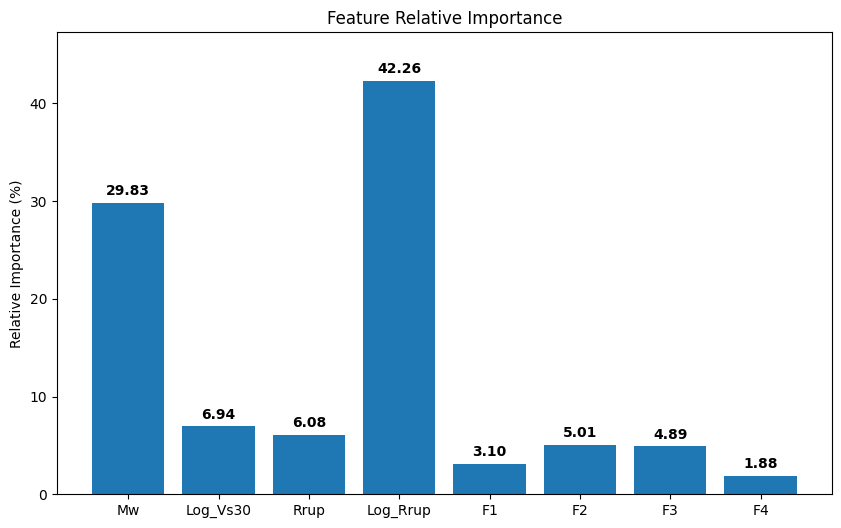

Plotting SHAP for PGA (Output 0)...


C:\Users\vishnu vardhan\AppData\Local\Temp\ipykernel_36792\104931983.py:138: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[0], X_test_sample, feature_names=feature_names, show=False)


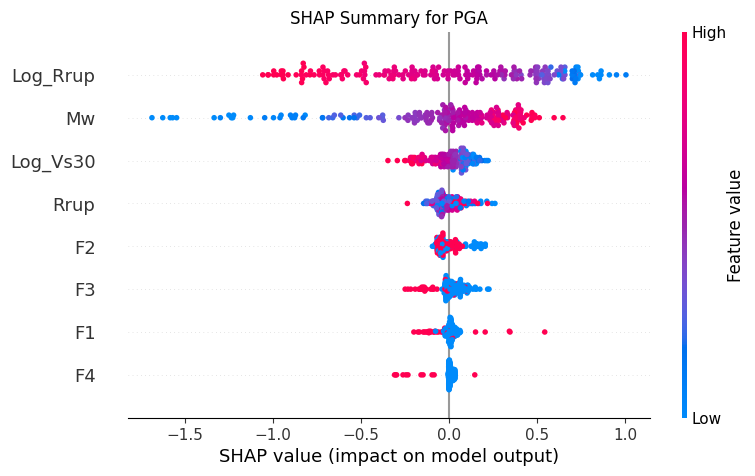

Plotting SHAP for PGV (Output 1)...


C:\Users\vishnu vardhan\AppData\Local\Temp\ipykernel_36792\104931983.py:143: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[1], X_test_sample, feature_names=feature_names, show=False)


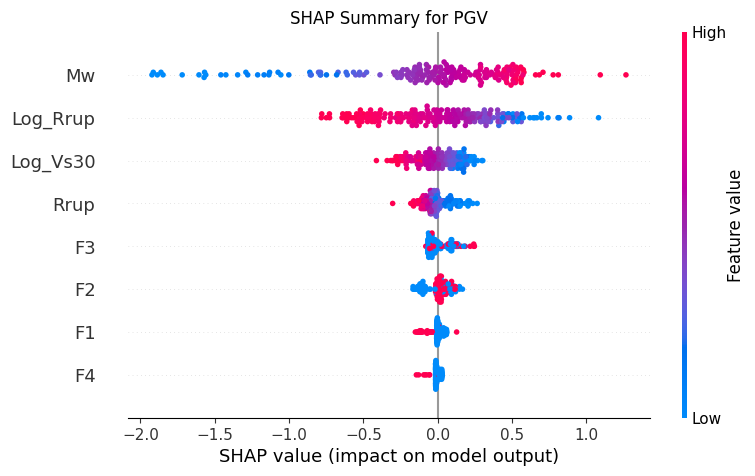

Plotting SHAP for PSA at 0.2s (Output 21)...


C:\Users\vishnu vardhan\AppData\Local\Temp\ipykernel_36792\104931983.py:148: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[idx_02s], X_test_sample, feature_names=feature_names, show=False)


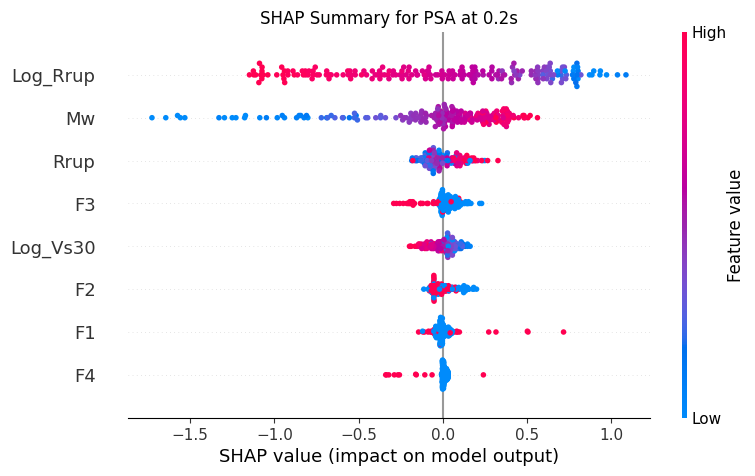

Plotting SHAP for PSA at 1s (Output 21)...


C:\Users\vishnu vardhan\AppData\Local\Temp\ipykernel_36792\104931983.py:153: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[idx_1s], X_test_sample, feature_names=feature_names, show=False)


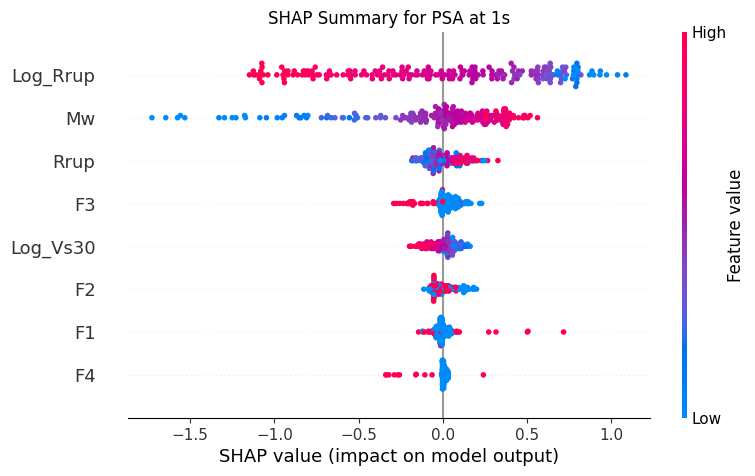

In [ ]:
# ==========================================
# 3) PARAMETRIC STUDIES
# ==========================================
import re

# Extract numerical periods from your sa_cols (e.g., 'T0pt010S' -> 0.01)
periods = []
for col in sa_cols:
    val = col.replace('T', '').replace('S', '').replace('pt', '.')
    periods.append(float(val))
periods = np.array(periods)

# Set up baseline inputs for the parametric study
base_M = 6.0
base_V = 500.0  # m/s
base_R = 50.0   # km
base_F = np.array([[1, 0, 0, 0]]) # Assuming Fault_Type 1 as baseline

# Function to generate a scaled input row for prediction
def create_input_row(M, R, V, F):
    log_V = np.log10(V)
    log_R = np.log10(R + epsilon)
    row_num = np.array([[M, log_V, R, log_R]])
    row = np.hstack([row_num, F])
    return scaler_X.transform(row)

# --- A) Parametric Study w.r.t Magnitude ---
M_list = [4.0, 5.0, 6.0, 7.0, 7.5]

plt.figure(figsize=(8, 6))
for M in M_list:
    row_scaled = create_input_row(M, base_R, base_V, base_F)
    pred_log_Y = final_model.predict(row_scaled, verbose=0)[0]
    pred_SA = 10**pred_log_Y[2:] # Skip PGA and PGV, take only SA values
    plt.loglog(periods, pred_SA, label=f'Mw = {M}')

plt.xlabel('Period (s)')
plt.ylabel('Spectral Acceleration (g)')
plt.title('Parametric Study w.r.t Magnitude')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

# --- B) Parametric Study w.r.t Rupture Distance ---
R_list = [10, 22.36, 50, 111.80, 250]

plt.figure(figsize=(8, 6))
for R in R_list:
    row_scaled = create_input_row(base_M, R, base_V, base_F)
    pred_log_Y = final_model.predict(row_scaled, verbose=0)[0]
    pred_SA = 10**pred_log_Y[2:]
    plt.loglog(periods, pred_SA, label=f'Rrup = {R} km')

plt.xlabel('Period (s)')
plt.ylabel('Spectral Acceleration (g)')
plt.title('Parametric Study w.r.t Rupture Distance')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

# --- C) Parametric Study w.r.t Velocity (Vs30) ---
V_list = [150, 225, 525, 1070, 1500]

plt.figure(figsize=(8, 6))
for V in V_list:
    row_scaled = create_input_row(base_M, base_R, V, base_F)
    pred_log_Y = final_model.predict(row_scaled, verbose=0)[0]
    pred_SA = 10**pred_log_Y[2:]
    plt.loglog(periods, pred_SA, label=f'Vs30 = {V} m/s')

plt.xlabel('Period (s)')
plt.ylabel('Spectral Acceleration (g)')
plt.title('Parametric Study w.r.t Shear Wave Velocity (Vs30)')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


# ==========================================
# 4) RELATIVE IMPORTANCE AND SHAP ANALYSIS
# ==========================================
import shap

# Feature names corresponding to your columns
feature_names = ["Mw", "Log_Vs30", "Rrup", "Log_Rrup", "F1", "F2", "F3", "F4"]

# To save time, use a random background sample for SHAP
np.random.seed(42)
background_idx = np.random.choice(X_train.shape[0], 100, replace=False)
background = X_train[background_idx]

# Sample from test set to explain
test_idx = np.random.choice(X_test.shape[0], 200, replace=False)
X_test_sample = X_test[test_idx]

# Initialize DeepExplainer
explainer = shap.DeepExplainer(final_model, background)
shap_values_raw = explainer.shap_values(X_test_sample)

# --- THE FIX: Format SHAP values based on library version ---
# If SHAP returns a 3D array (samples, features, outputs), convert it to a list of (samples, features)
if isinstance(shap_values_raw, np.ndarray) and len(shap_values_raw.shape) == 3:
    shap_values = [shap_values_raw[:, :, i] for i in range(shap_values_raw.shape[2])]
# If it returns an Explanation object (very newest SHAP versions)
elif hasattr(shap_values_raw, 'values') and len(shap_values_raw.values.shape) == 3:
    shap_values = [shap_values_raw.values[:, :, i] for i in range(shap_values_raw.values.shape[2])]
# If it's already a list (older SHAP versions)
else:
    shap_values = shap_values_raw

# 4a) Relative Importance (%) Bar Chart
# Aggregate mean absolute SHAP values across all outputs and instances
mean_abs_shap = np.zeros(X.shape[1])
for i in range(len(shap_values)):
    # Now shap_values[i] correctly corresponds to a single output of shape (200, 8)
    mean_abs_shap += np.mean(np.abs(shap_values[i]), axis=0)

# Calculate percentages
rel_importance = 100 * mean_abs_shap / np.sum(mean_abs_shap)

plt.figure(figsize=(10, 6))
bars = plt.bar(feature_names, rel_importance, color='#1f77b4')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.2f}", ha='center', va='bottom', fontweight='bold')

plt.ylabel("Relative Importance (%)")
plt.title("Feature Relative Importance")
plt.ylim(0, max(rel_importance) + 5)
plt.show()

# 4b) SHAP Summary Plots
# We need to find the specific column indices for PSA 0.2s and 1s.
idx_02s = 2 + np.argmin(np.abs(periods - 0.2)) # Offset by 2 for PGA, PGV
idx_1s = 2 + np.argmin(np.abs(periods - 1.0))  # Offset by 2 for PGA, PGV

print("Plotting SHAP for PGA (Output 0)...")
shap.summary_plot(shap_values[0], X_test_sample, feature_names=feature_names, show=False)
plt.title("SHAP Summary for PGA")
plt.show()

print("Plotting SHAP for PGV (Output 1)...")
shap.summary_plot(shap_values[1], X_test_sample, feature_names=feature_names, show=False)
plt.title("SHAP Summary for PGV")
plt.show()

print(f"Plotting SHAP for PSA at 0.2s (Output {idx_02s})...")
shap.summary_plot(shap_values[idx_02s], X_test_sample, feature_names=feature_names, show=False)
plt.title("SHAP Summary for PSA at 0.2s")
plt.show()

print(f"Plotting SHAP for PSA at 1s (Output {idx_1s})...")
shap.summary_plot(shap_values[idx_1s], X_test_sample, feature_names=feature_names, show=False)
plt.title("SHAP Summary for PSA at 1s")
plt.show()

Step-by-Step: Additive Neural Network (for PGA only first)

In [ ]:
# Individual inputs (from already filtered & masked data)
Mw = X[:, 0:1]          # Mw
logVs30 = X[:, 1:2]     # log(Vs30)
Rrup = X[:, 3:4]        # log(Rrup)
Fault = X[:, 4:]        # one-hot fault

# PGA output only
Y_pga = Y[:, 0:1]


In [ ]:
Mw_tr, Mw_te, \
R_tr, R_te, \
Vs_tr, Vs_te, \
F_tr, F_te, \
Ytr, Yte = train_test_split(
    Mw, Rrup, logVs30, Fault, Y_pga,
    test_size=0.2,
    random_state=42
)


In [ ]:
from tensorflow.keras.layers import Input, Dense, Add
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


In [ ]:
# Mw branch
inp_M = Input(shape=(1,))
f_M = Dense(8, activation='relu')(inp_M)
f_M = Dense(1, activation='linear')(f_M)

# Rrup branch
inp_R = Input(shape=(1,))
f_R = Dense(8, activation='relu')(inp_R)
f_R = Dense(1, activation='linear')(f_R)

# Vs30 branch
inp_V = Input(shape=(1,))
f_V = Dense(8, activation='relu')(inp_V)
f_V = Dense(1, activation='linear')(f_V)

# Fault branch (linear is enough)
inp_F = Input(shape=(4,))
f_F = Dense(1, activation='linear')(inp_F)


In [ ]:
out = Add()([f_M, f_R, f_V, f_F])

additive_model = Model(
    inputs=[inp_M, inp_R, inp_V, inp_F],
    outputs=out
)

additive_model.compile(
    optimizer=Adam(learning_rate=3e-3),
    loss='mse',
    metrics=['mae']
)

additive_model.summary()


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_17      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_18      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_19      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 8)         │         16 │ input_layer_17[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_36 (Dense)    │ (None, 8)         │         16 │ input_layer_18[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_38 (Dense)    │ (None, 8)         │         16 │ input_layer_19[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_20      │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_35 (Dense)    │ (None, 1)         │          9 │ dense_34[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_37 (Dense)    │ (None, 1)         │          9 │ dense_36[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_39 (Dense)    │ (None, 1)         │          9 │ dense_38[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_40 (Dense)    │ (None, 1)         │          5 │ input_layer_20[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1)         │          0 │ dense_35[0][0],   │
│                     │                   │            │ dense_37[0][0],   │
│                     │                   │            │ dense_39[0][0],   │
│                     │                   │            │ dense_40[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 80 (320.00 B)

 Trainable params: 80 (320.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_add = additive_model.fit(
    [Mw_tr, R_tr, Vs_tr, F_tr],
    Ytr,
    validation_split=0.2,
    epochs=120,
    batch_size=64,
    verbose=1
)


Epoch 1/120
457/457 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1729 - mae: 0.3107 - val_loss: 0.1764 - val_mae: 0.3099
Epoch 2/120
457/457 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1903 - mae: 0.3118 - val_loss: 0.1759 - val_mae: 0.3093
Epoch 3/120
457/457 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1825 - mae: 0.3091 - val_loss: 0.1791 - val_mae: 0.3125
Epoch 4/120
457/457 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1852 - mae: 0.3131 - val_loss: 0.1903 - val_mae: 0.3253
Epoch 5/120
457/457 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1923 - mae: 0.3208 - val_loss: 0.1758 - val_mae: 0.3087
Epoch 6/120
457/457 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1868 - mae: 0.3127 - val_loss: 0.1757 - val_mae: 0.3094
Epoch 7/120
457/457 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1790 - mae: 0.3101 - val_loss: 0.1759 - val_mae: 0.3090
Epoch 8/120
457/457 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1783 - mae: 0.3090 - val_loss: 0.1791 - val_mae: 0.3133
Epoch 9/120
457/457 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/

In [ ]:
test_mse, test_mae = additive_model.evaluate(
    [Mw_te, R_te, Vs_te, F_te],
    Yte,
    verbose=0
)

print("Additive NN Test MAE (PGA):", test_mae)


Additive NN Test MAE (PGA): 0.3101617395877838


Mandatory Plots for Additive NN

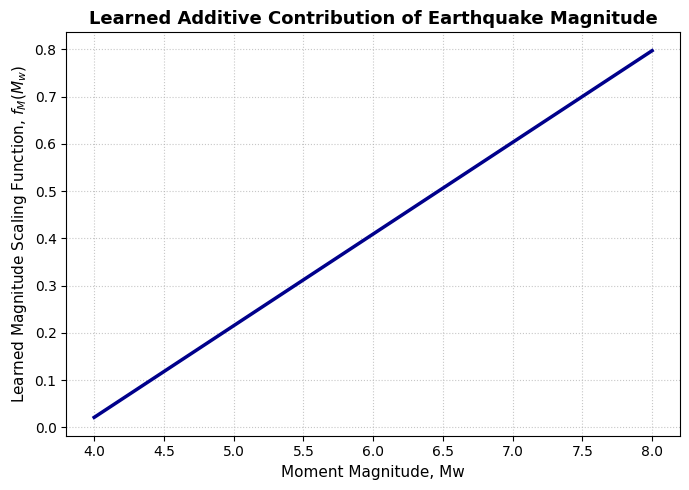

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(
    Mw_grid,
    fM_vals,
    linewidth=2.5,
    color='darkblue'
)

plt.xlabel("Moment Magnitude, Mw", fontsize=11)
plt.ylabel(r"Learned Magnitude Scaling Function, $f_M(M_w)$", fontsize=11)

plt.title(
    "Learned Additive Contribution of Earthquake Magnitude",
    fontsize=13,
    fontweight='bold'
)

plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()



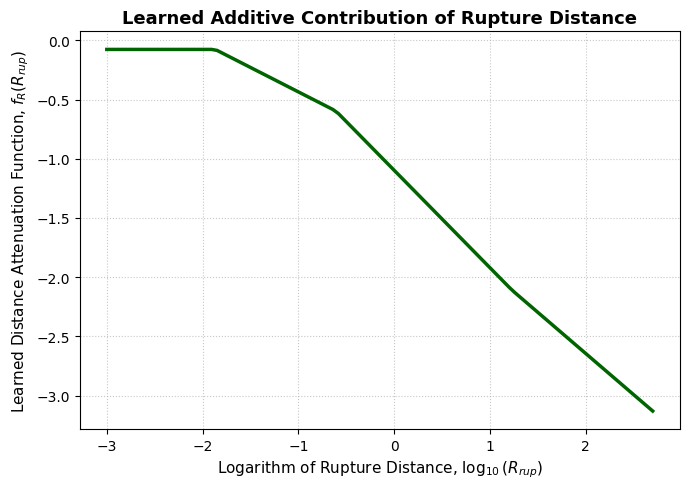

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(
    R_grid,
    fR_vals,
    linewidth=2.5,
    color='darkgreen'
)

plt.xlabel(r"Logarithm of Rupture Distance, $\log_{10}(R_{rup})$", fontsize=11)
plt.ylabel(r"Learned Distance Attenuation Function, $f_R(R_{rup})$", fontsize=11)

plt.title(
    "Learned Additive Contribution of Rupture Distance",
    fontsize=13,
    fontweight='bold'
)

plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()


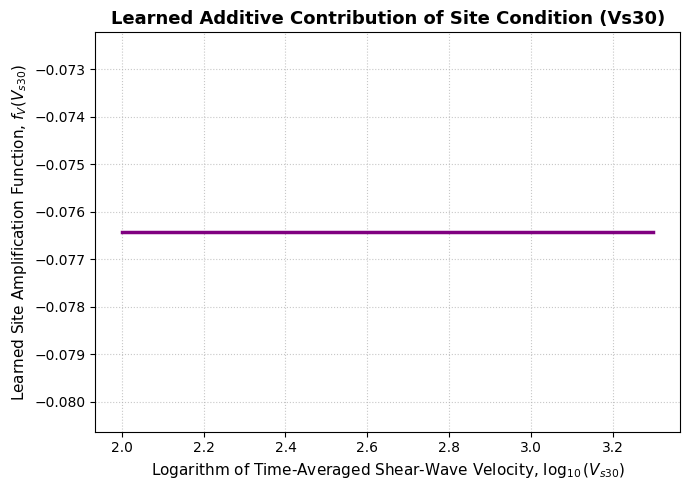

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(
    Vs_grid,
    fV_vals,
    linewidth=2.5,
    color='purple'
)

plt.xlabel(
    r"Logarithm of Time-Averaged Shear-Wave Velocity, $\log_{10}(V_{s30})$",
    fontsize=11
)
plt.ylabel(
    r"Learned Site Amplification Function, $f_V(V_{s30})$",
    fontsize=11
)

plt.title(
    "Learned Additive Contribution of Site Condition (Vs30)",
    fontsize=13,
    fontweight='bold'
)

plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()



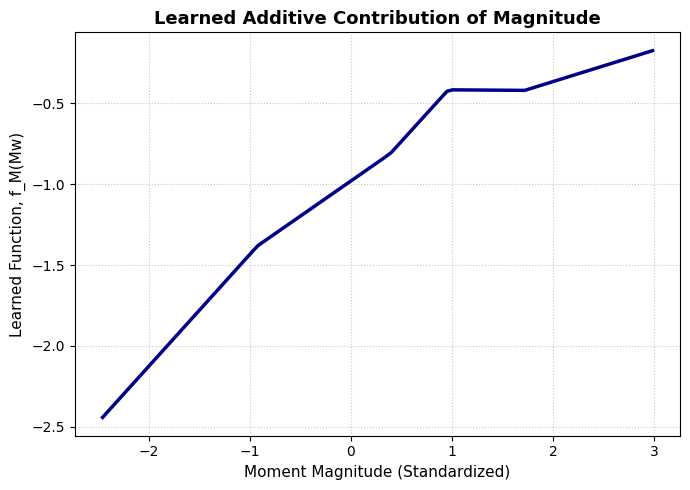

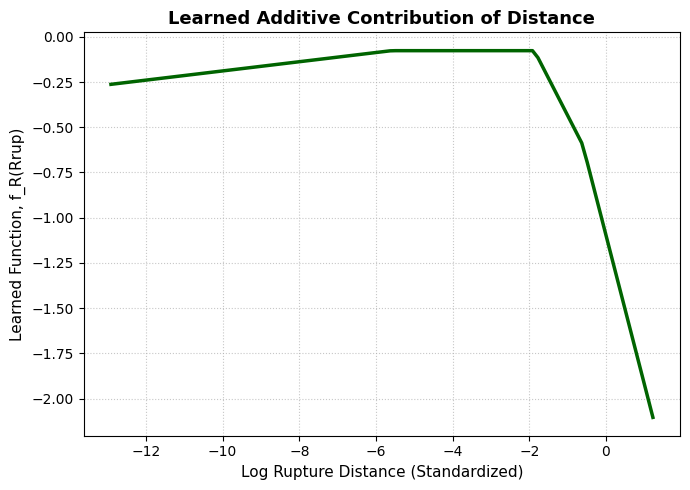

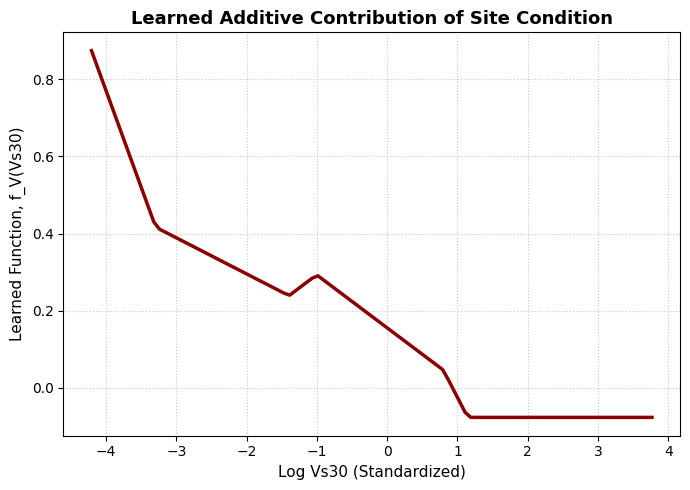

In [ ]:
# ==========================================
# Mandatory Plots for Additive NN
# ==========================================

# 1. Define sub-models to extract the isolated learned functions
model_M = Model(inputs=inp_M, outputs=f_M)
model_R = Model(inputs=inp_R, outputs=f_R)
model_V = Model(inputs=inp_V, outputs=f_V)

# 2. Generate input grids (using the min and max of your standardized inputs)
Mw_grid = np.linspace(X[:, 0].min(), X[:, 0].max(), 100).reshape(-1,1)
R_grid = np.linspace(X[:, 3].min(), X[:, 3].max(), 100).reshape(-1,1) # Log_Rrup
V_grid = np.linspace(X[:, 1].min(), X[:, 1].max(), 100).reshape(-1,1)  # Log_Vs30

# 3. Predict the additive contributions
fM_vals = model_M.predict(Mw_grid, verbose=0)
fR_vals = model_R.predict(R_grid, verbose=0)
fV_vals = model_V.predict(V_grid, verbose=0)

# 4. Plotting

# --- Plot 1: Magnitude ---
plt.figure(figsize=(7,5))
plt.plot(Mw_grid, fM_vals, linewidth=2.5, color='darkblue')
plt.xlabel("Moment Magnitude (Standardized)", fontsize=11)
plt.ylabel("Learned Function, f_M(Mw)", fontsize=11)
plt.title("Learned Additive Contribution of Magnitude", fontsize=13, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Plot 2: Rupture Distance ---
plt.figure(figsize=(7,5))
plt.plot(R_grid, fR_vals, linewidth=2.5, color='darkgreen')
plt.xlabel("Log Rupture Distance (Standardized)", fontsize=11)
plt.ylabel("Learned Function, f_R(Rrup)", fontsize=11)
plt.title("Learned Additive Contribution of Distance", fontsize=13, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Plot 3: Shear Wave Velocity (Vs30) ---
plt.figure(figsize=(7,5))
plt.plot(V_grid, fV_vals, linewidth=2.5, color='darkred')
plt.xlabel("Log Vs30 (Standardized)", fontsize=11)
plt.ylabel("Learned Function, f_V(Vs30)", fontsize=11)
plt.title("Learned Additive Contribution of Site Condition", fontsize=13, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()